In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# data set loading

In [3]:
df=pd.read_csv("Credit Card Defaulter Prediction.csv")

In [4]:
# understanding the dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         30000 non-null  int64 
 1   LIMIT_BAL  30000 non-null  int64 
 2   SEX        30000 non-null  object
 3   EDUCATION  30000 non-null  object
 4   MARRIAGE   30000 non-null  object
 5   AGE        30000 non-null  int64 
 6   PAY_0      30000 non-null  int64 
 7   PAY_2      30000 non-null  int64 
 8   PAY_3      30000 non-null  int64 
 9   PAY_4      30000 non-null  int64 
 10  PAY_5      30000 non-null  int64 
 11  PAY_6      30000 non-null  int64 
 12  BILL_AMT1  30000 non-null  int64 
 13  BILL_AMT2  30000 non-null  int64 
 14  BILL_AMT3  30000 non-null  int64 
 15  BILL_AMT4  30000 non-null  int64 
 16  BILL_AMT5  30000 non-null  int64 
 17  BILL_AMT6  30000 non-null  int64 
 18  PAY_AMT1   30000 non-null  int64 
 19  PAY_AMT2   30000 non-null  int64 
 20  PAY_AMT3   30000 non-null  i

In [6]:
df.shape

(30000, 25)

In [7]:
df.describe()

,ID,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,8660.398374,129747.661567,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,1.000000,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,15000.500000,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,22500.250000,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,30000.000000,1000000.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


# checking the null values in dataset 

df.isnull().sum()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default '],
      dtype='object')

In [12]:
df=df.drop(columns='ID')

# observations
- no duplicates are present
- no null values are present
- 20 features are numerical features and remaining are categorical features

# univariate analysis

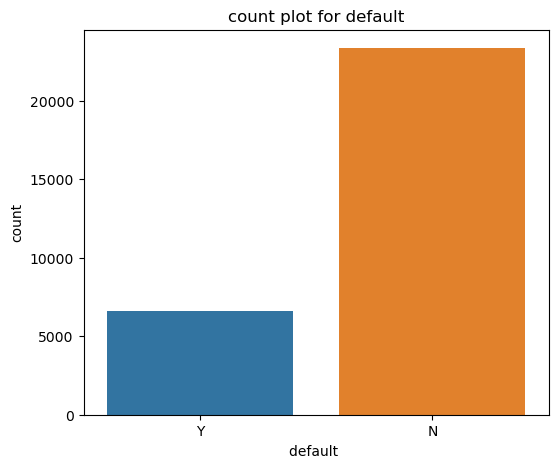

In [14]:
# count plot
plt.figure(figsize=(6,5))
sns.countplot(x = 'default ', data = df,hue='default ')
plt.title('count plot for default')
plt.show()

# lets check categorical features independent variables

In [16]:
cat=df.select_dtypes(include='object').columns

In [17]:
cat

Index(['SEX', 'EDUCATION', 'MARRIAGE', 'default '], dtype='object')

# value counts

In [19]:
df['SEX'].value_counts()

SEX
F    18112
M    11888
Name: count, dtype: int64

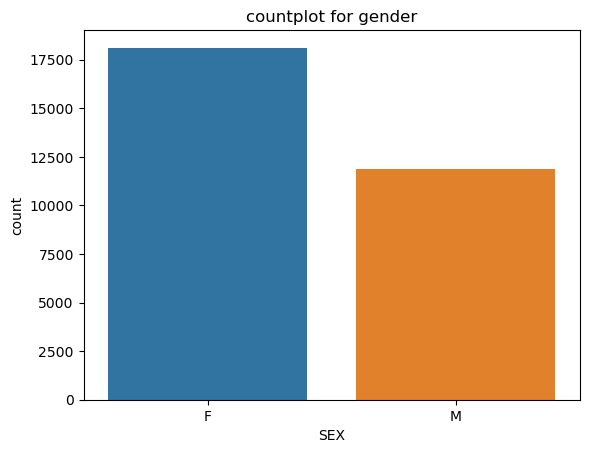

In [20]:
# count plot

sns.countplot(x='SEX',data=df,hue='SEX')
plt.title('countplot for gender')
plt.show()

In [21]:
df['EDUCATION'].value_counts()

EDUCATION
University         14030
Graduate school    10585
High School         4917
Unknown              331
Others               123
0                     14
Name: count, dtype: int64

<Axes: xlabel='EDUCATION', ylabel='count'>

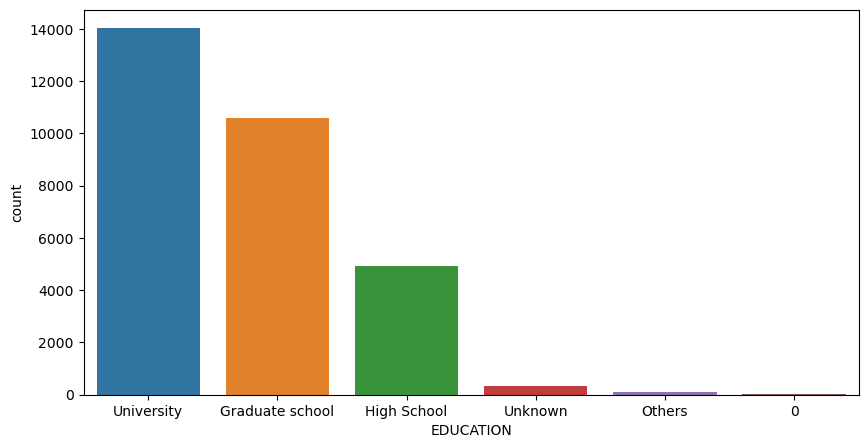

In [22]:
# count plot

plt.figure(figsize=(10,5))
sns.countplot(x="EDUCATION",data=df,hue='EDUCATION')


In [23]:
df['MARRIAGE'].value_counts()

MARRIAGE
Single     15964
Married    13659
Other        323
0             54
Name: count, dtype: int64

In [24]:
df[df['MARRIAGE']=='0']

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
218,110000,F,High School,0,31,0,0,0,0,0,...,73315,63818,63208,4000,5000,3000,3000,3000,8954,N
809,160000,F,University,0,37,0,0,0,0,0,...,28574,27268,28021,35888,1325,891,1000,1098,426,N
820,200000,F,High School,0,51,-1,-1,-1,-1,0,...,780,390,390,0,390,780,0,390,390,N
1019,180000,F,High School,0,45,-1,-1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,N
1443,200000,M,High School,0,51,-1,-1,-1,-1,0,...,2529,1036,4430,5020,9236,2529,0,4430,6398,N
2146,150000,F,High School,0,55,-1,-1,-1,-1,-1,...,2939,3396,1870,17498,9160,2939,3396,1870,6800,N
2554,220000,F,Graduate school,0,33,-1,-1,-1,-1,-1,...,608,1738,277,1531,942,608,1738,277,492,N
3056,200000,M,High School,0,36,-2,-2,-2,-2,-2,...,41359,9140,0,89187,14178,41359,9140,0,0,N
4470,70000,M,High School,0,35,2,2,2,2,2,...,50517,51658,52758,2200,1900,2000,2100,2100,2000,N
5005,90000,F,High School,0,24,-2,-2,-2,-1,0,...,13574,6800,1830,20108,4000,13574,14,5,13162,N


In [25]:
num=df.select_dtypes(include='number').columns

In [26]:
num

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

# univariate analysis

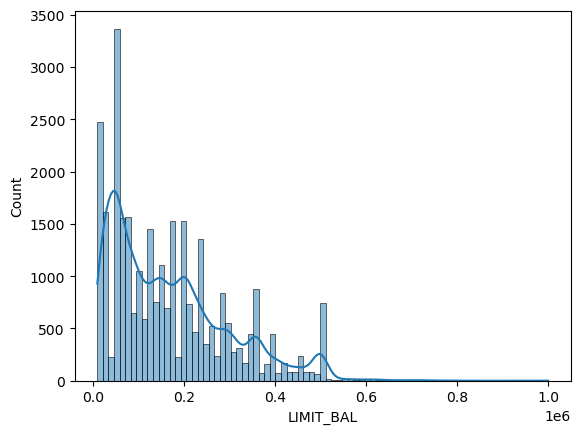

In [27]:
# histplot

sns.histplot(df,x='LIMIT_BAL',kde=True)
plt.show()

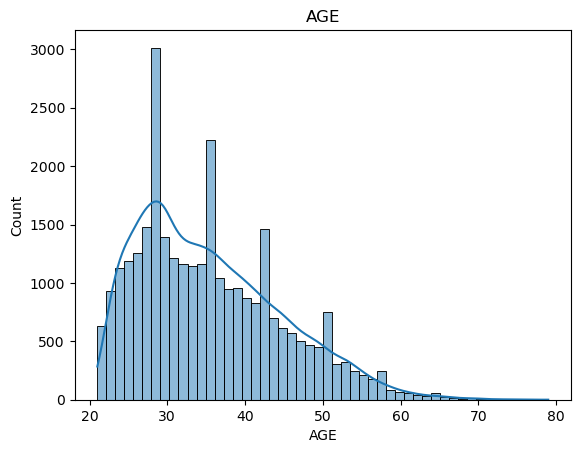

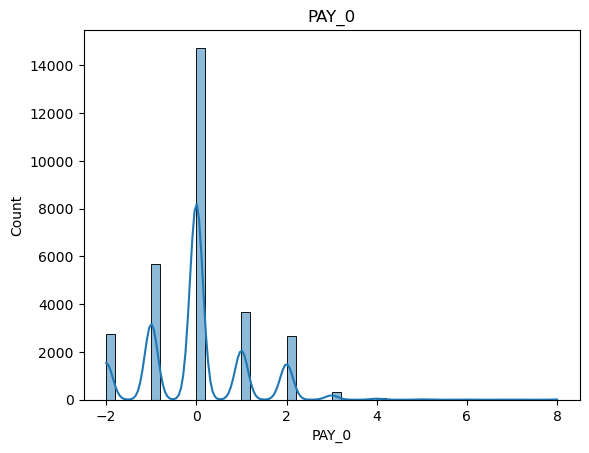

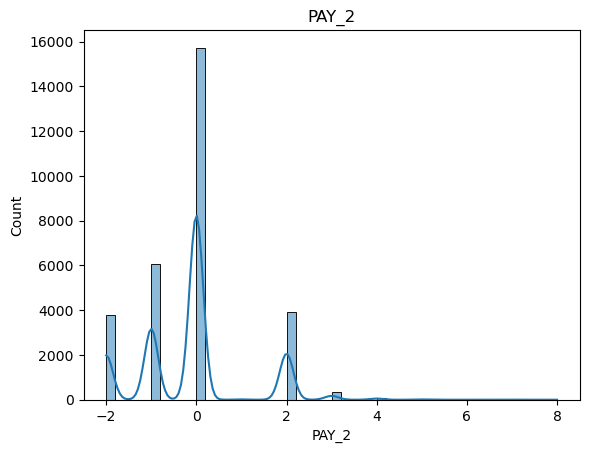

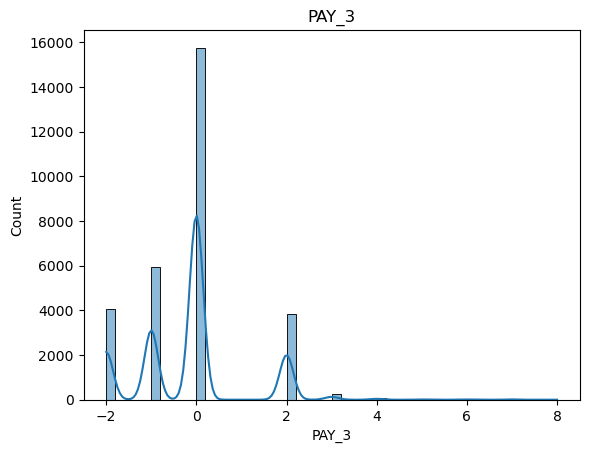

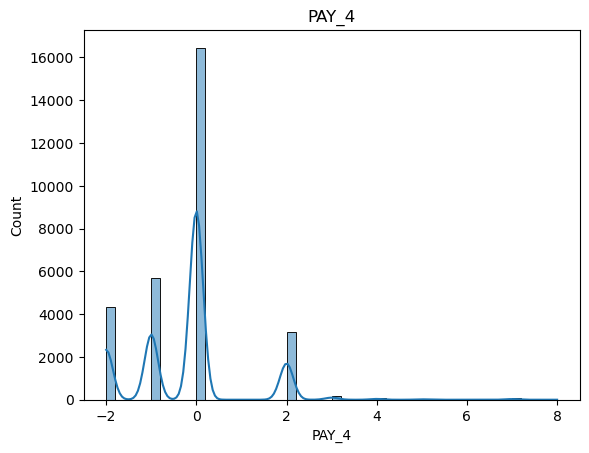

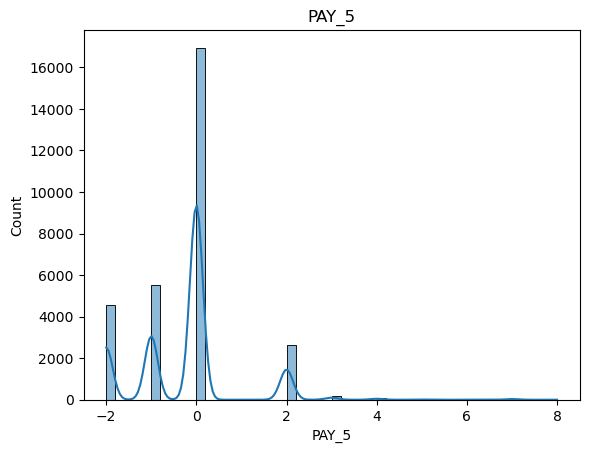

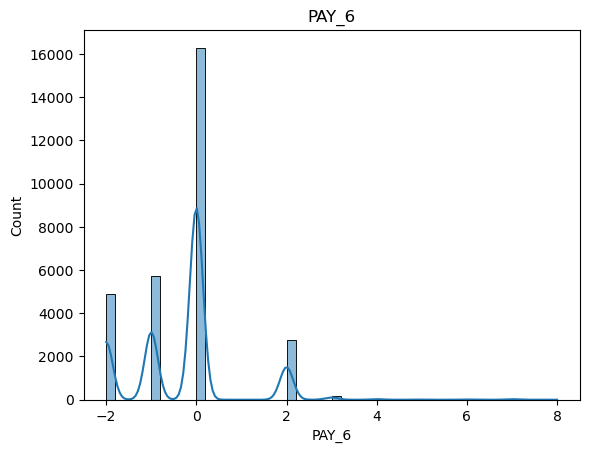

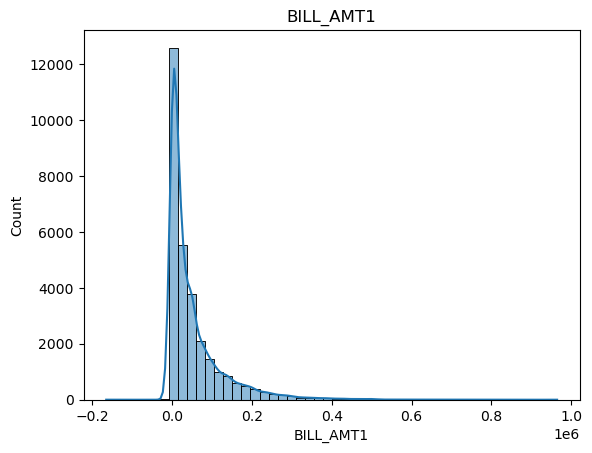

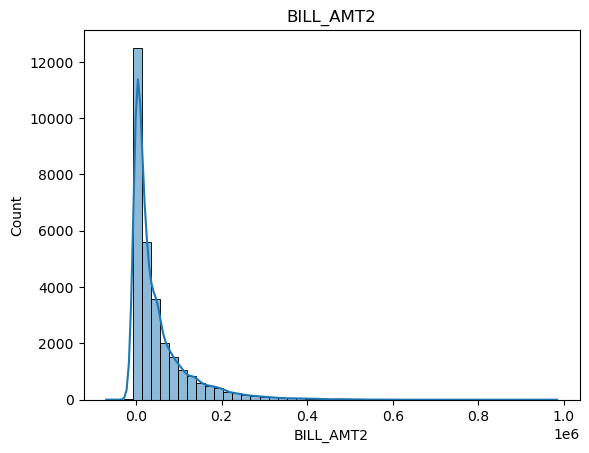

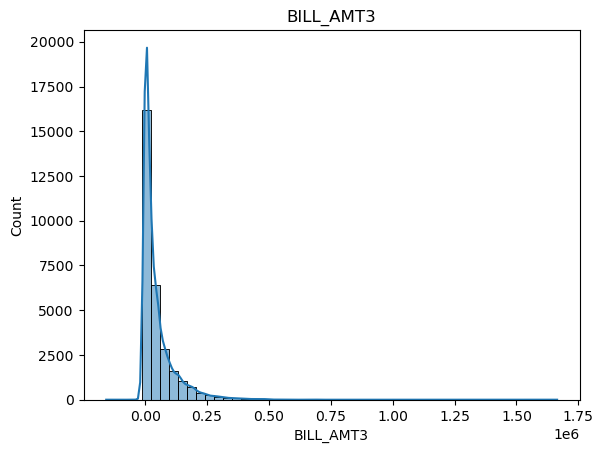

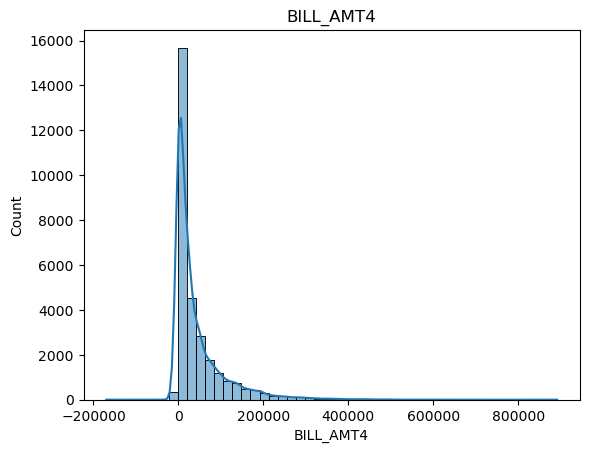

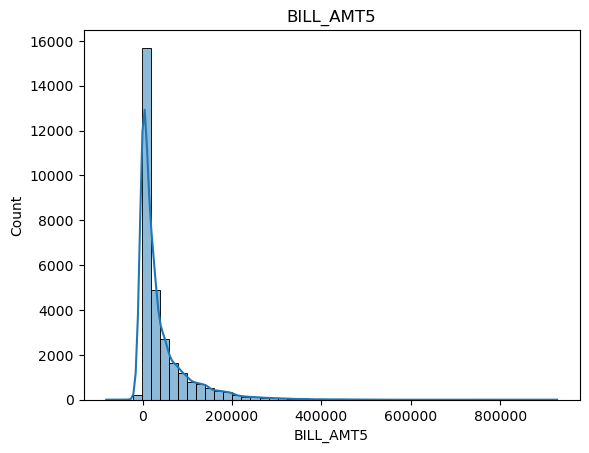

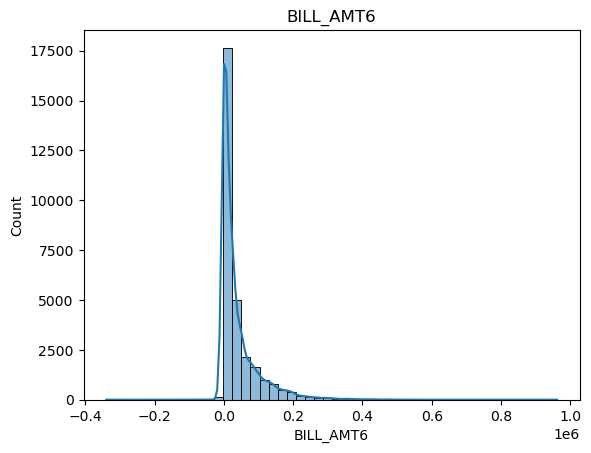

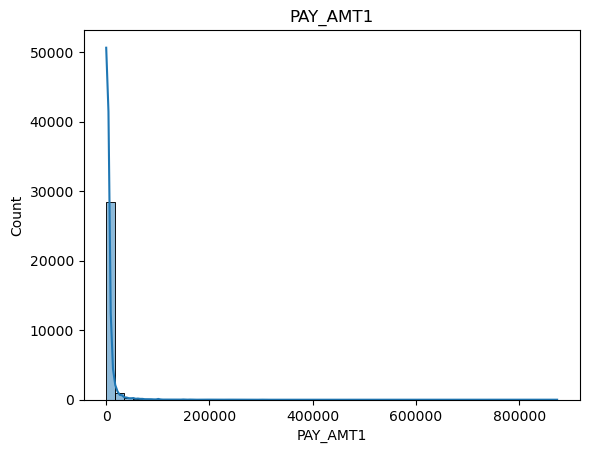

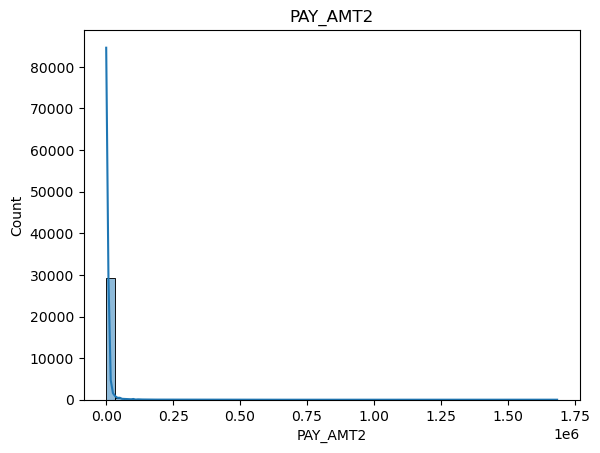

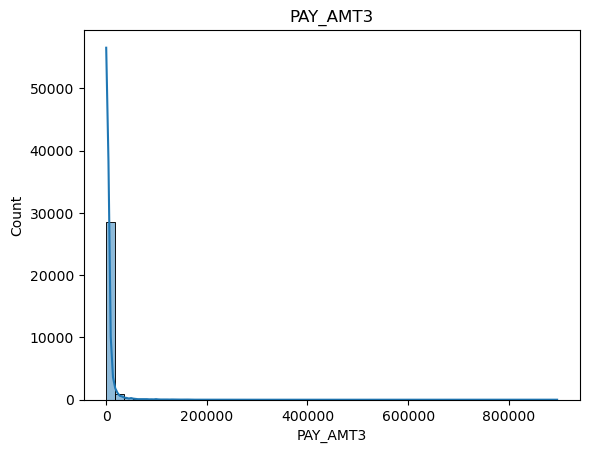

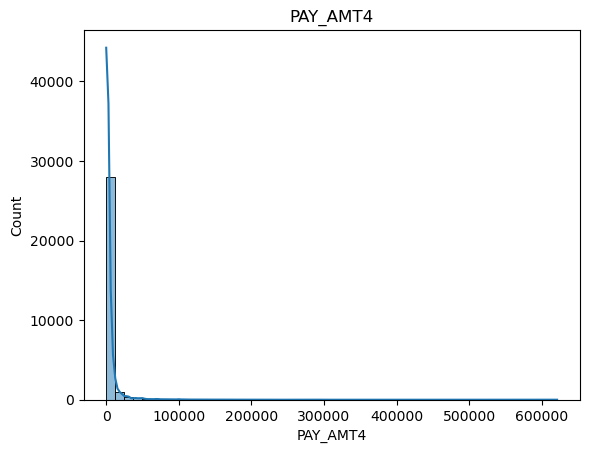

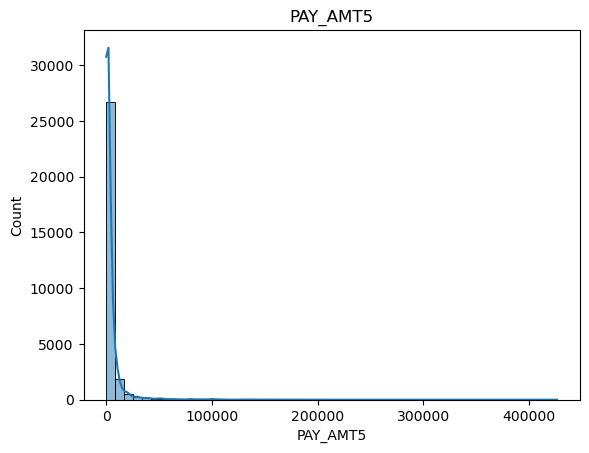

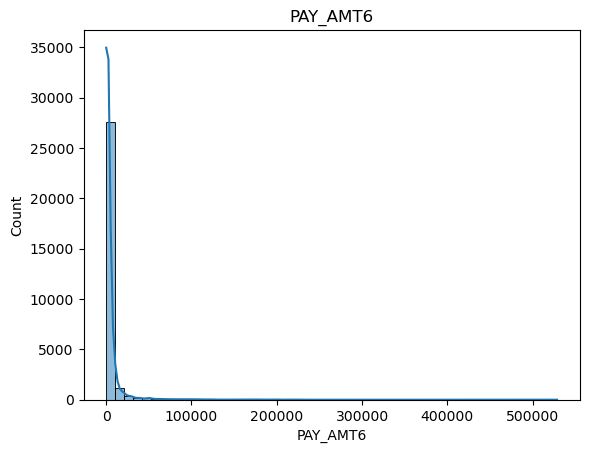

In [28]:
for i in num[1:]:
    sns.histplot(df,x=i,bins=50,kde=True)
    plt.title(i)
    plt.show()

# insights
- Limit bal every customer has different limit balance
- Customers are distributed across different age groups, with the majority concentrated in the adult working-age range.
- the data is rightly skeweed in bill_amt,pay_amt

# bi variate analysis

In [39]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default '],
      dtype='object')

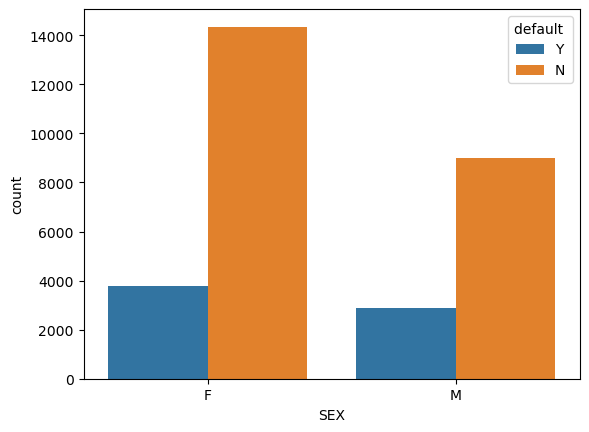

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='SEX', hue='default ')
plt.show()

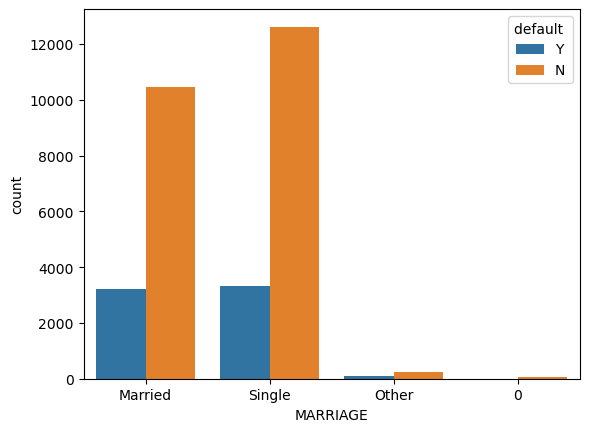

In [42]:


sns.countplot(data=df, x='MARRIAGE', hue='default ')
plt.show()

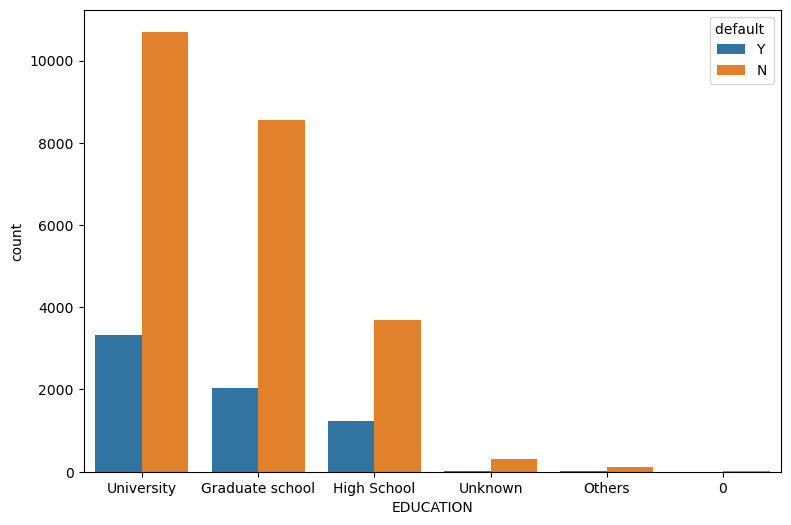

In [44]:
plt.figure(figsize=(9,6))
sns.countplot(data=df, x='EDUCATION', hue='default ')
plt.show()

# scatter plots

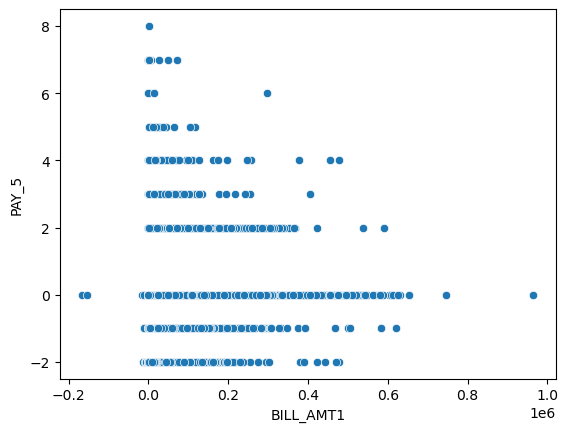

In [47]:
sns.scatterplot(df,x='BILL_AMT1',y='PAY_5')
plt.show()

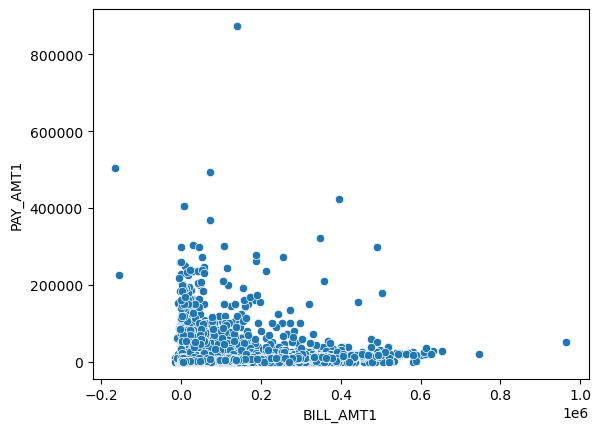

In [48]:
sns.scatterplot(df,x='BILL_AMT1',y='PAY_AMT1')
plt.show()

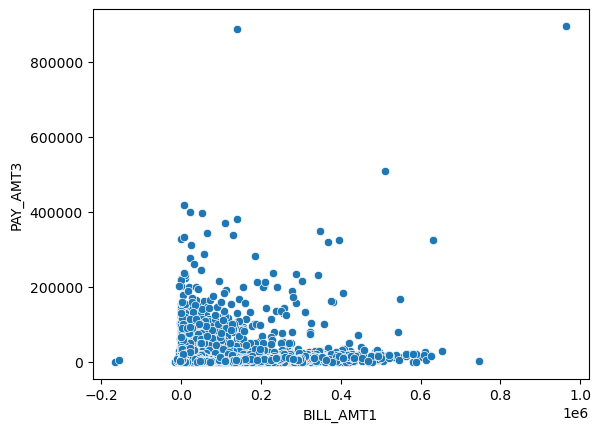

In [52]:
sns.scatterplot(df,x='BILL_AMT1',y='PAY_AMT3')
plt.show()

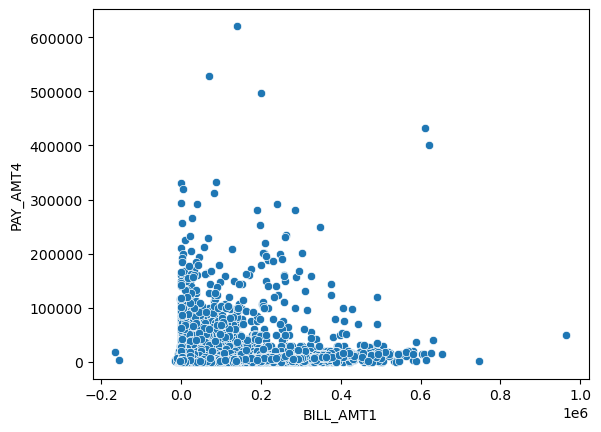

In [53]:
sns.scatterplot(df,x='BILL_AMT1',y='PAY_AMT4')
plt.show()

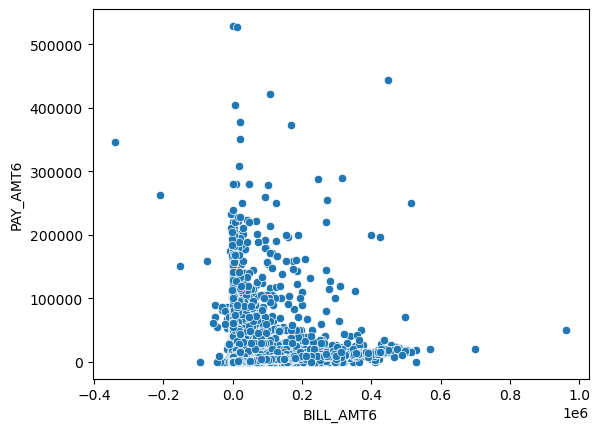

In [54]:
sns.scatterplot(df,x='BILL_AMT6',y='PAY_AMT6')
plt.show()

# Insights
- females are more number in less risk compared to males
- singles and married one has less risk
- higher education has more number of non defaults that means customers are paying the bill corectly according the analyis

# box plot

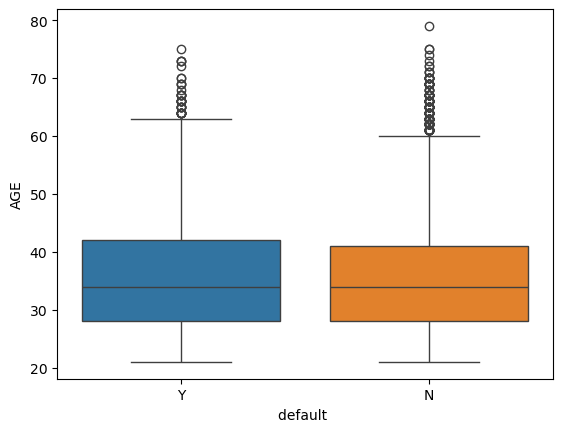

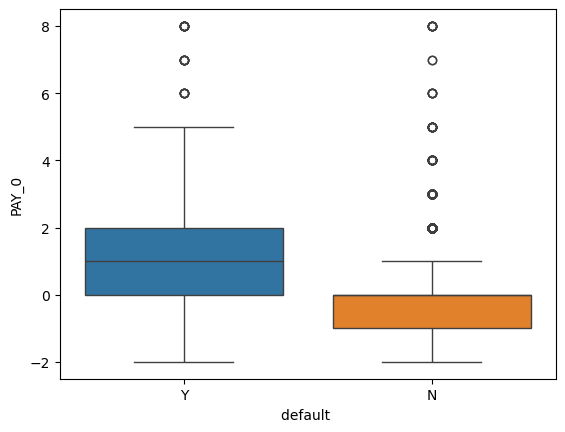

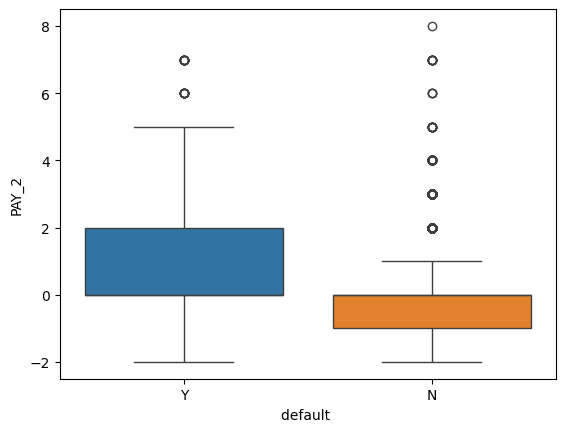

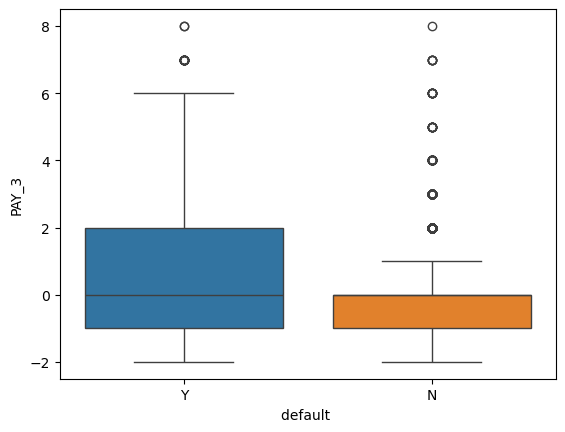

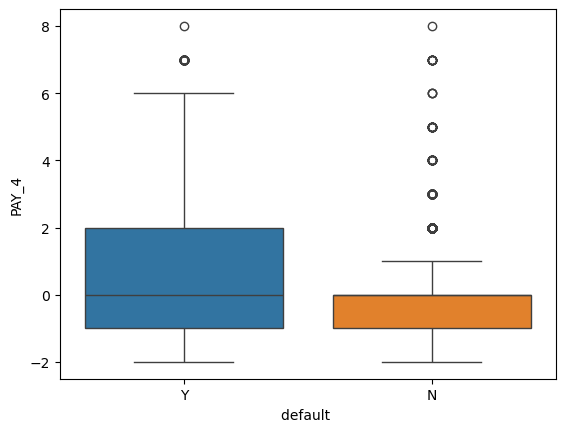

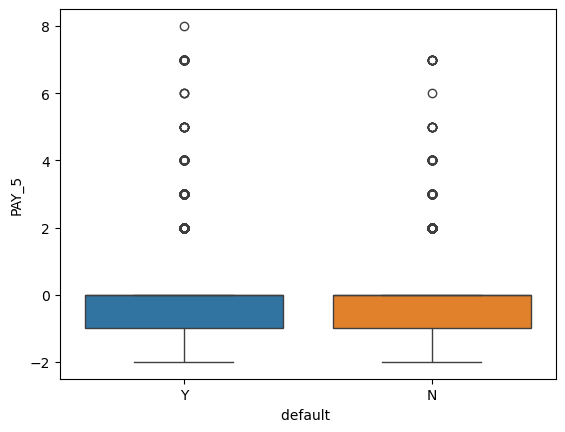

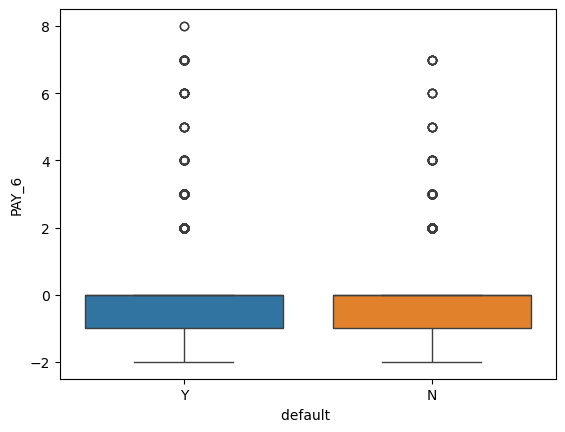

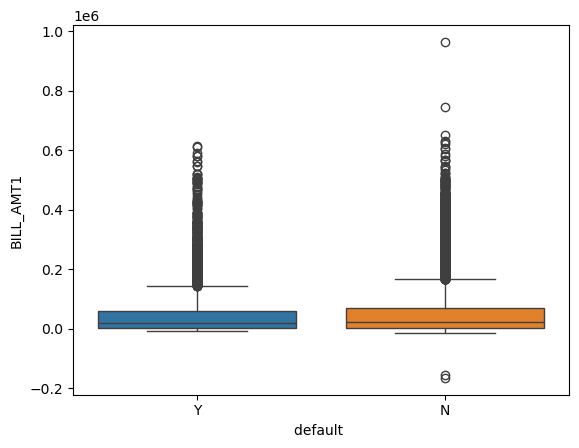

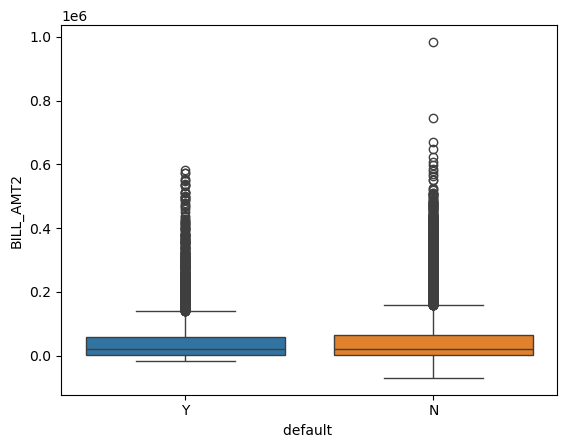

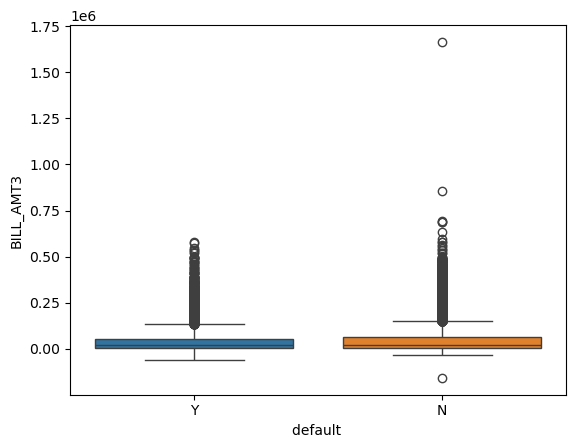

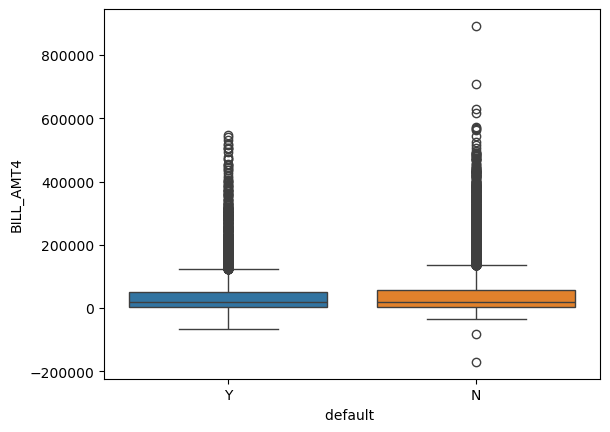

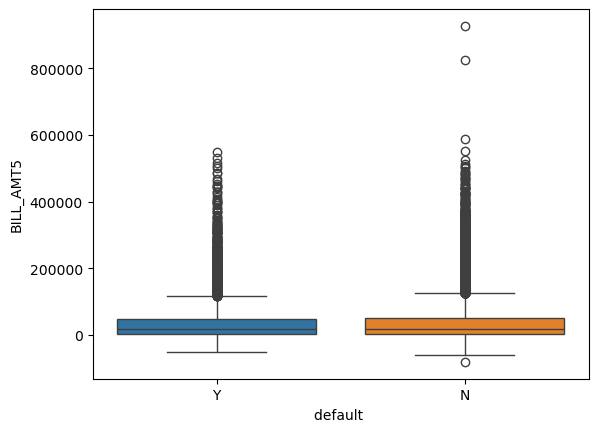

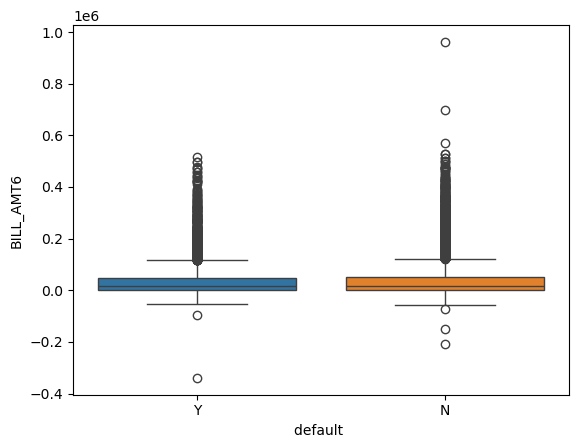

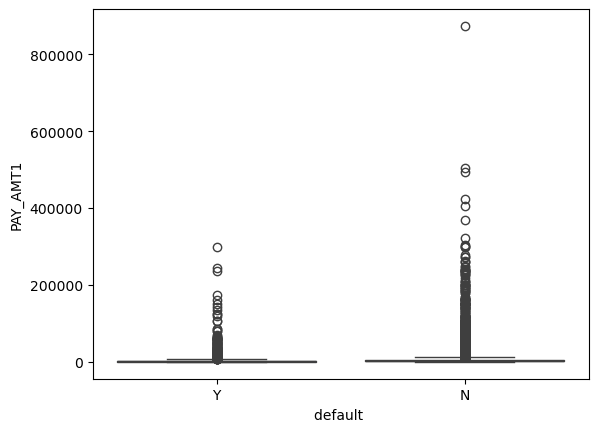

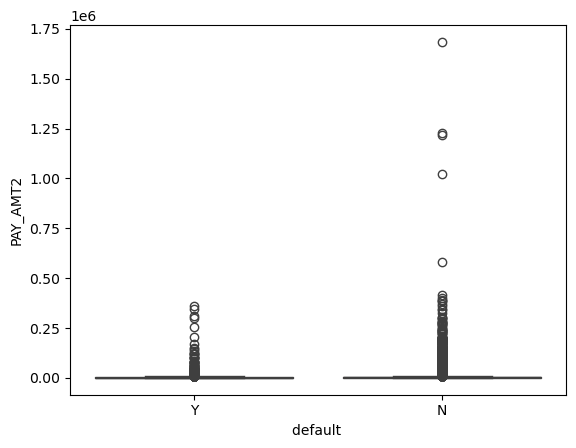

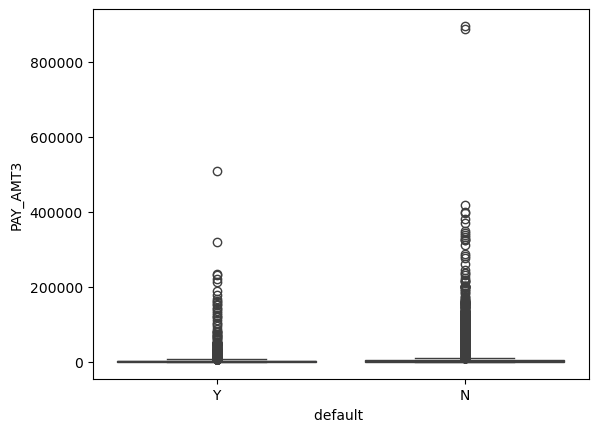

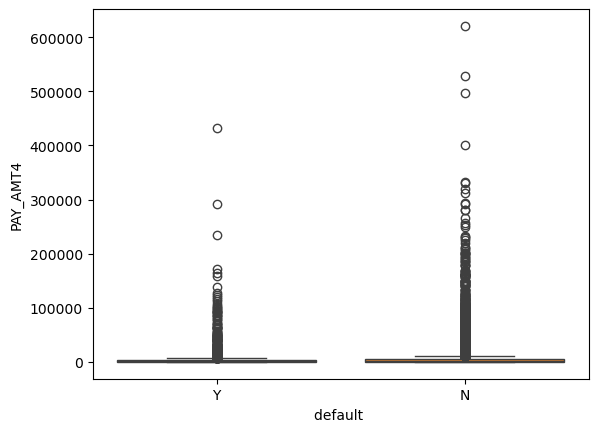

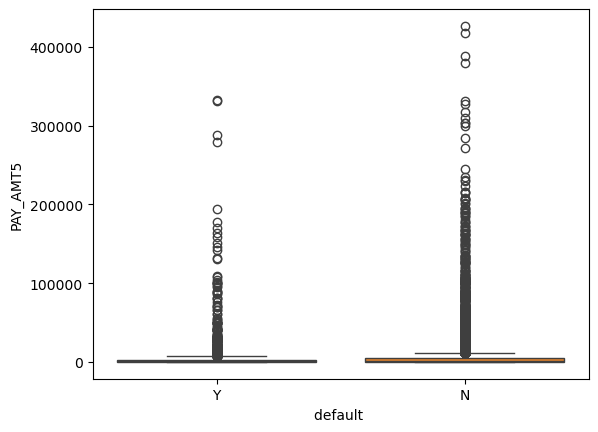

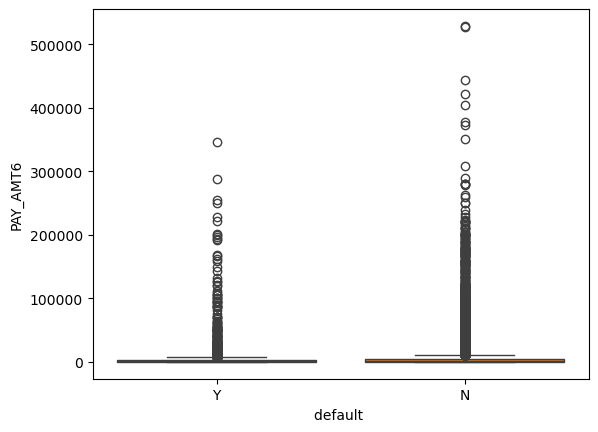

In [32]:
for i in num[1:]:
    sns.boxplot(df,y=i,x='default ',hue='default ')
    plt.show()

# insights
- there are outliers present in evry column
- some columns has extream outliers whic can be effect the analysis

# correlation

In [34]:
nums=df[1:].select_dtypes(include='number')

In [57]:
corr=nums.corr()

<Axes: >

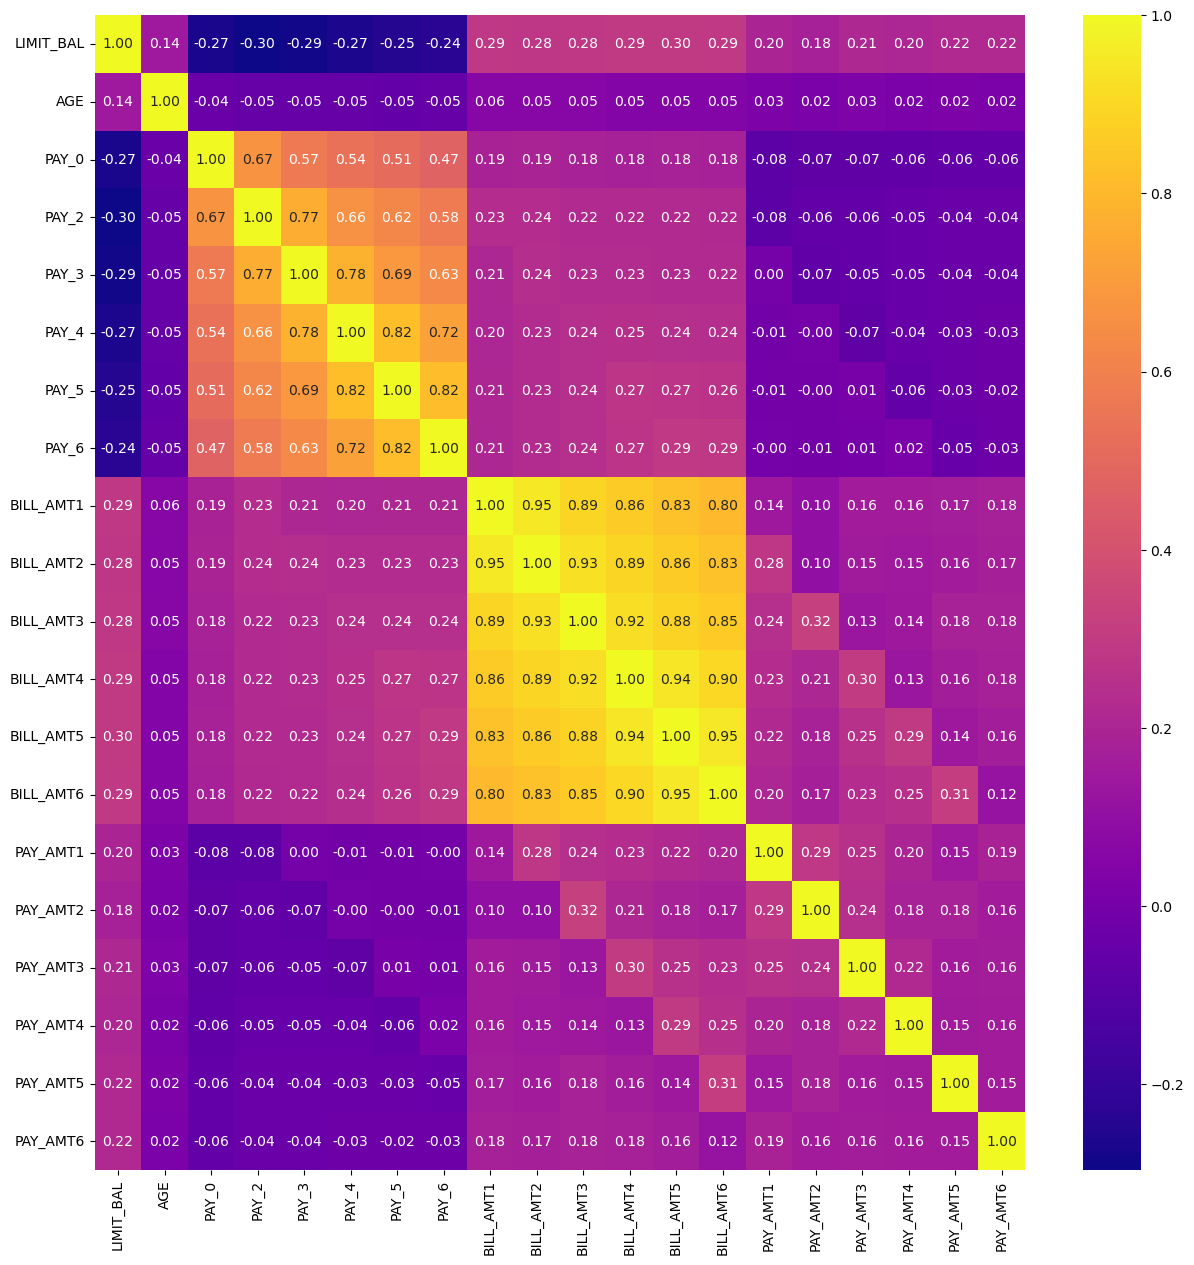

In [58]:
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True,cmap='plasma',fmt='.2f')

# insights

- Bill amounts across different months are strongly positively correlated, indicating consistency in customers' billing patterns.
 Payment amounts across different months show relationships, reflecting customers' payment behavior over time.
- Payment-status variables across months are related, suggesting that past repayment behavior can provide information about future      repayment behavior.
- Credit limit has a positive relationship with several bill-amount variables, indicating that credit exposure is associated with       spending/billing levels.
- The heatmap helps identify correlated features and potential multicollinearity, which should be considered during feature selection and model building.

# pair plot

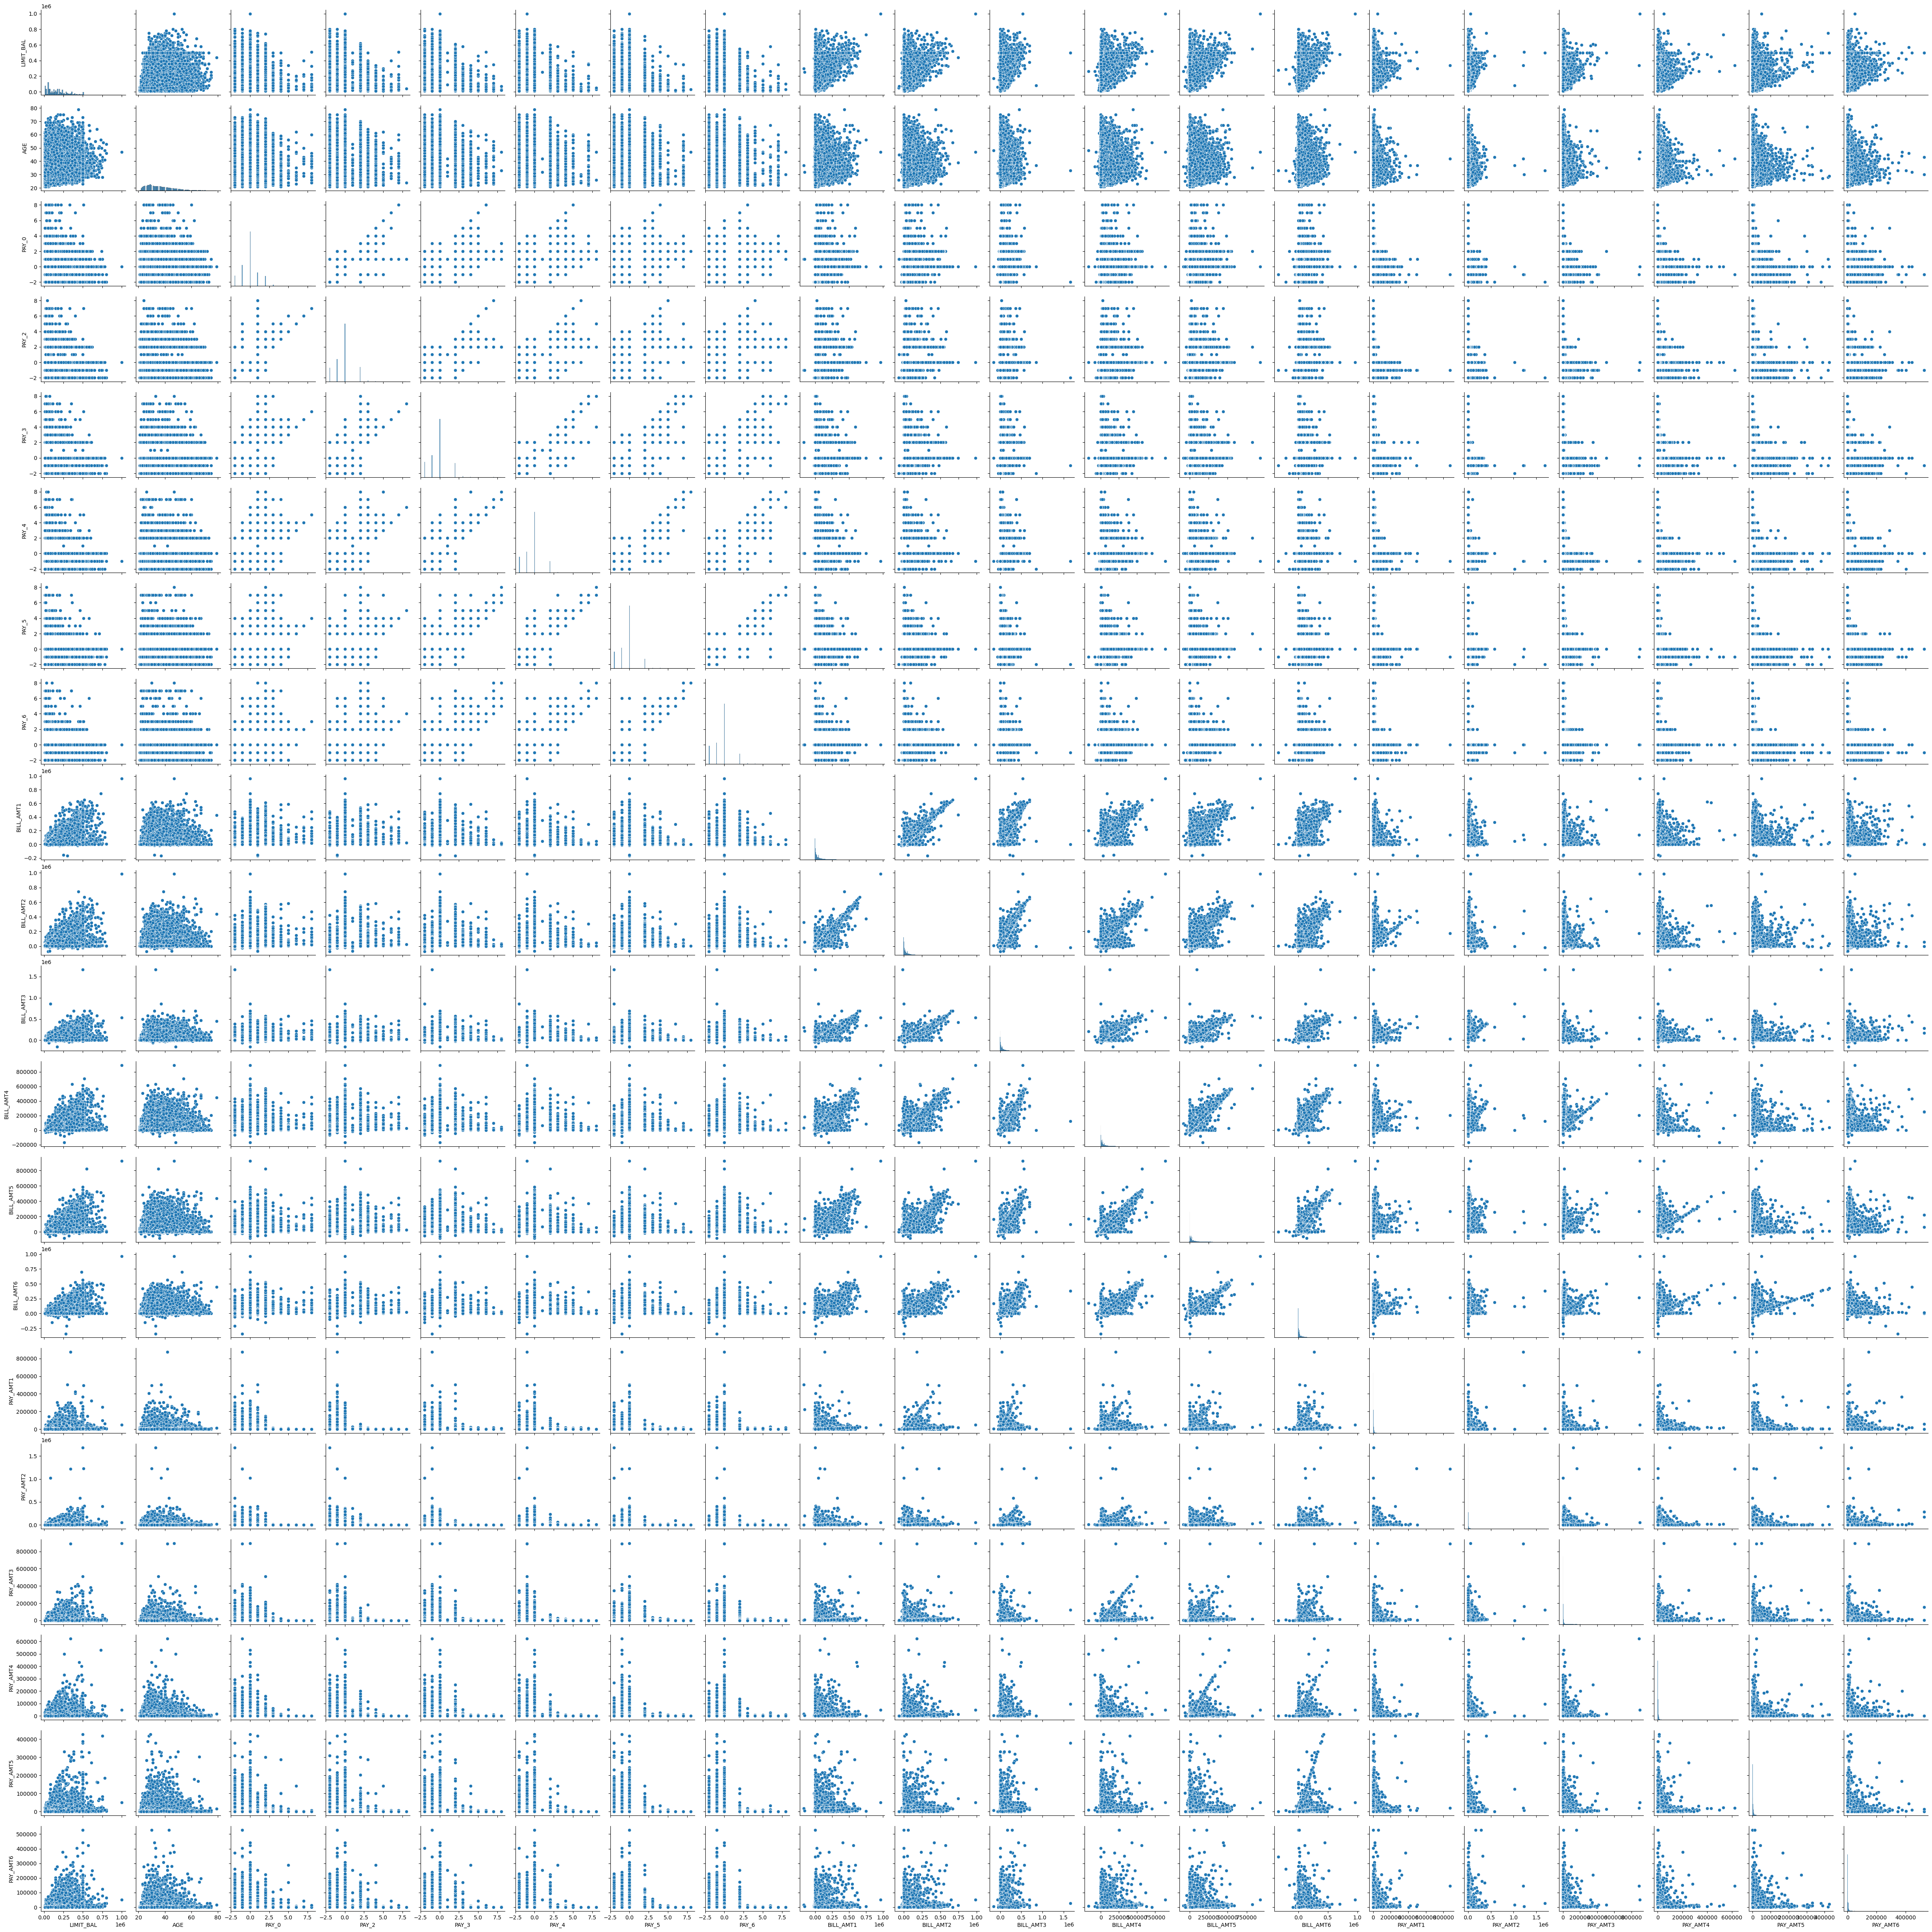

In [51]:
sns.pairplot(df[1:].select_dtypes(include='number' ))



# Overall EDA Insights

* The dataset contains **30,000 customer records**.
* There are **no missing values or duplicate records**.
* `ID` was removed because it is only an identifier.
* Most customers belong to the **University and Graduate School** education categories.
* Most customers are **Single or Married**.
* There are more **female customers than male customers**.
* `LIMIT_BAL` shows that customers have different levels of credit limits.
* `BILL_AMT` shows differences in customers' monthly billing amounts.
* `PAY_AMT` shows differences in customers' payment amounts.
* `PAY_0` to `PAY_6` show customers' **payment history over different months**.
* Bivariate analysis helps us compare **default and non-default customers** across different categories.
* The heatmap shows that several monthly bill and payment variables are **correlated with each other**.
* Box plots help identify **differences between defaulters and non-defaulters** and detect outliers.
* Overall, **payment history, bill amounts, payment amounts and credit limit** are important variables to consider for predicting credit-card default.
